#Data Exploration, Cleaning, and Preprocessing

## Cleaning the original dataset

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
#Read in the dataset
full_data = pd.read_csv('https://raw.githubusercontent.com/snehasri2600/Water-Quality-Jamaica-Bay/main/Jamaica-Bay-dataset.csv')

#Display data as downloaded
display(full_data)

,Sampling Location,Duplicate Sample,Sample Date,Sample Time,Weather Condition (Dry or Wet),Top Sample Temperature (ºC),Site Actual Depth (ft),Top Sample Depth(ft),Top Salinity (psu),Top Conductivity (S/m),...,Top PCB Plate Count (Thous/mL),Top Coliform (Log No/mL),Oakwood BOD Top Sample (mg/L),Oakwood Total Suspended Solid Top Sample (mg/L),Oakwood Total Suspended Solid Bottom Sample (mg/L),Top Turbidity( Nephelometric Turbidity Units),Sampling Comment,Long,Lat,Type
0,J1,NaN,6/29/1909,1:20 PM,NaN,20.50000,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent
1,J1,NaN,6/29/1909,1:20 PM,NaN,20.50000,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent
2,J1,NaN,6/29/1909,1:30 PM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent
3,J1,NaN,6/29/1909,3:04 PM,NaN,19.00000,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent
4,J1,NaN,9/17/1909,11:00 AM,NaN,19.50000,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12127,N9,NaN,10/8/2024,11:20,NaN,19.37600,20.0,3.0,29.38760,4.043915,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent
12128,N9,NaN,10/16/2024,10:10,Dry,16.23275,17.0,3.0,30.13915,3.860118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent
12129,N9,NaN,10/22/2024,9:56,NaN,16.02035,18.0,3.0,29.39530,3.756258,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent
12130,N9,NaN,11/13/2024,11:00,Dry,13.22430,17.0,3.0,30.28570,3.616698,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent


We are only looking at values from 1995-2024. We can remove all values from before 1995.

In [3]:
# Convert 'Sample Date' to datetime objects
full_data['Sample Date'] = pd.to_datetime(full_data['Sample Date'], errors='coerce')

#Removing values before 1995
data_since_1995 = full_data[full_data['Sample Date'].dt.year >= 1995]
print(f"Shape of data_since_1995: {data_since_1995.shape}")
display(data_since_1995.head())

Shape of data_since_1995: (6910, 61)


,Sampling Location,Duplicate Sample,Sample Date,Sample Time,Weather Condition (Dry or Wet),Top Sample Temperature (ºC),Site Actual Depth (ft),Top Sample Depth(ft),Top Salinity (psu),Top Conductivity (S/m),...,Top PCB Plate Count (Thous/mL),Top Coliform (Log No/mL),Oakwood BOD Top Sample (mg/L),Oakwood Total Suspended Solid Top Sample (mg/L),Oakwood Total Suspended Solid Bottom Sample (mg/L),Top Turbidity( Nephelometric Turbidity Units),Sampling Comment,Long,Lat,Type
886,J1,NaN,1995-01-05,11:36 AM,NaN,4.64,31.0,6.56,29.29,2.82,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent
887,J1,NaN,1995-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent
888,J1,NaN,1995-02-16,11:44 AM,NaN,1.58,30.0,3.28,28.73,2.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent
889,J1,NaN,1995-03-21,10:46 AM,NaN,6.57,39.0,3.28,28.80,2.93,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent
890,J1,NaN,1995-03-28,1:37 PM,NaN,NaN,34.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.884667,40.573333,Permanent


Standardize 'Weather Condition (Dry or Wet)' by mapping 'D' to 'Dry' and 'W' to 'Wet'.

In [4]:
#Look at dry/wet counts
print("Weather Condition Counts:")
print(data_since_1995['Weather Condition (Dry or Wet)'].value_counts())

#Standardize dry/wet counts
data_since_1995['Weather Condition (Dry or Wet)'] = data_since_1995['Weather Condition (Dry or Wet)'].replace({'D': 'Dry', 'W': 'Wet', 'WET':'Wet'})
print("Standardized Weather Condition Counts:")
print(data_since_1995['Weather Condition (Dry or Wet)'].value_counts())

Weather Condition Counts:
Weather Condition (Dry or Wet)
D      2657
W      1275
Dry    1053
Wet     524
WET       1
Name: count, dtype: int64
Standardized Weather Condition Counts:
Weather Condition (Dry or Wet)
Dry    3710
Wet    1800
Name: count, dtype: int64


Dealing with duplicate samples

In [5]:
# Seeing how duplicate samples are encoded in the dataset
print(data_since_1995['Duplicate Sample'].value_counts(dropna=False))

# Updating the dataset to only include 'Duplicate Sample' values that are NOT equal to 'D'
data_since_1995 = data_since_1995[data_since_1995['Duplicate Sample'] != 'D']
print(f"Shape of data after removing duplicate samples: {data_since_1995.shape}")

Duplicate Sample
NaN    6823
D        87
Name: count, dtype: int64
Shape of data after removing duplicate samples: (6823, 61)


Separate summer (June, July, August, September) and winter values

In [6]:
# Extract month from 'Sample Date'
data_since_1995['Month'] = data_since_1995['Sample Date'].dt.month

# Define a function to categorize seasons
def get_season(month):
    if 6 <= month <= 9:
        return 'Summer'
    else:
        return 'Winter'

# Apply the function to create a 'Season' column
data_since_1995['Season'] = data_since_1995['Month'].apply(get_season)

# Group by year and season, then count samples
seasonal_counts = data_since_1995.groupby([data_since_1995['Sample Date'].dt.year, 'Season']).size().unstack(fill_value=0)
seasonal_counts.index.name = 'Year'

print("Number of Samples per Year, separated by Season (Summer: June-Sept, Winter: Oct-May):")
print(seasonal_counts)

Number of Samples per Year, separated by Season (Summer: June-Sept, Winter: Oct-May):
Season  Summer  Winter
Year                  
1995        79     100
1996       100      80
1997       120      90
1998       109      68
1999       100      60
2000        85      49
2001        89      75
2002       150      49
2003       156      49
2004       159      80
2005       167      56
2006       144      76
2007       156      86
2008       169      79
2009       178      86
2010       174      98
2011       178      94
2012       170     116
2013       161     110
2014       160      80
2015       160     120
2016       158     102
2017       140     100
2018        98      94
2019       145     101
2020       110      78
2021       116      91
2022       160     140
2023       120     140
2024       144     121


Visualizing summer vs. winter counts

<Figure size 1800x700 with 0 Axes>

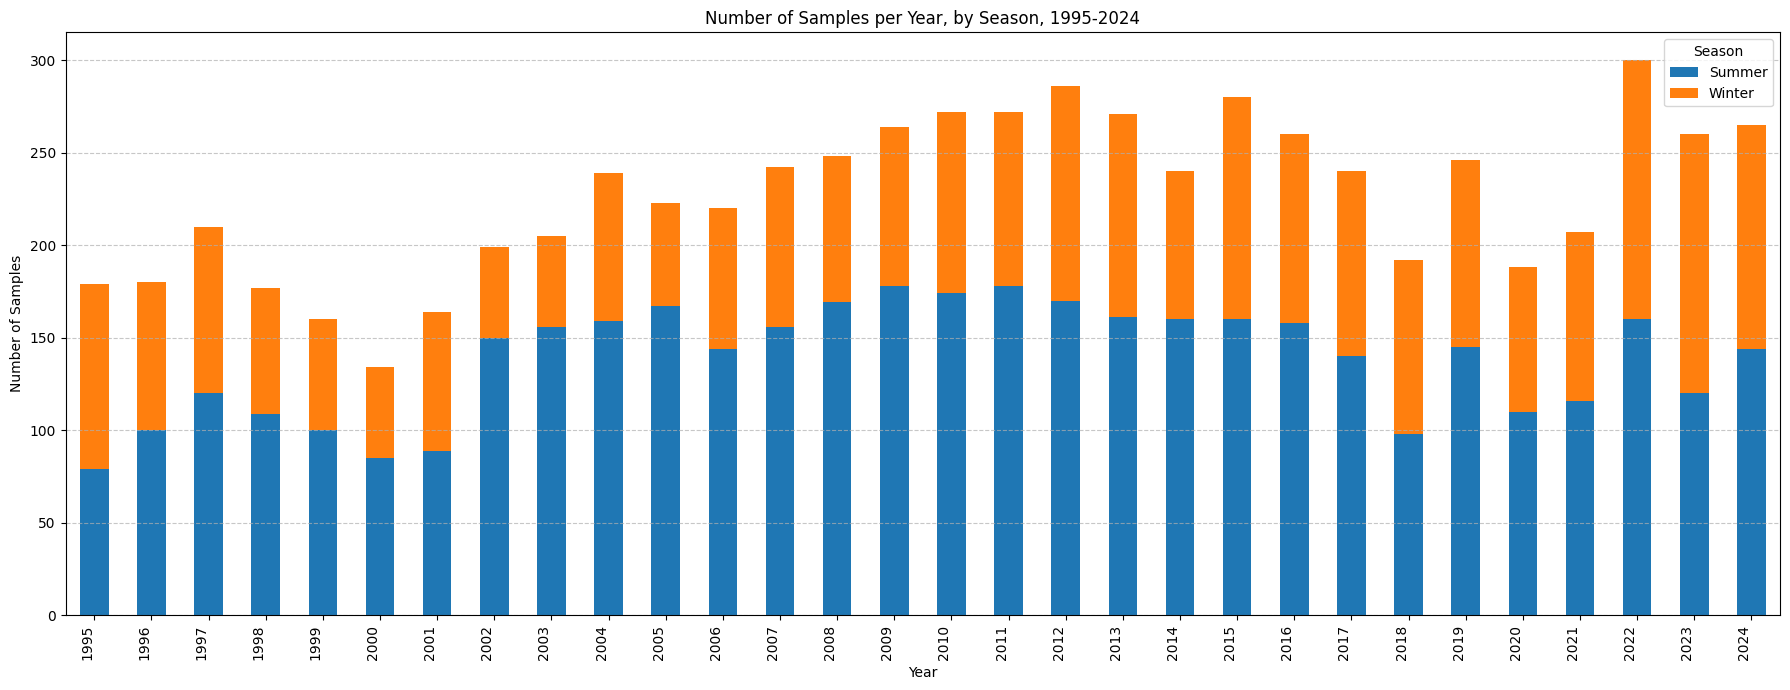

In [10]:
# Filter data_since_1995 for Summer season only
summer_data_since_1995 = data_since_1995[data_since_1995['Season'] == 'Summer']

# Group by year and weather condition, then count samples
summer_weather_counts = summer_data_since_1995.groupby([summer_data_since_1995['Sample Date'].dt.year, 'Weather Condition (Dry or Wet)']).size().unstack(fill_value=0)
summer_weather_counts.index.name = 'Year'

#Visualize the seasonal counts as listed above
plt.figure(figsize=(18, 7))
seasonal_counts.plot(kind='bar', stacked=True, figsize=(18, 7))
plt.title('Number of Samples per Year, by Season, 1995-2024')
plt.xlabel('Year')
plt.ylabel('Number of Samples')
plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for readability
plt.legend(title='Season')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Visualizing summer dry vs. wet weather counts since 1995

In [ ]:
#Filter the data for station J1
j1_data = summer_data_since_1995[summer_data_since_1995['Sampling Location'] == 'J1'].copy()
print(f"Shape of filtered data for station J1: {j1_data.shape}")
display(j1_data)

#Filter the data for station J3
j3_data = summer_data_since_1995[summer_data_since_1995['Sampling Location'] == 'J3'].copy()
print(f"Shape of filtered data for station J3: {j3_data.shape}")
display(j3_data)

In [ ]:
#Filter the data for station J7
j7_data = summer_data_since_1995[summer_data_since_1995['Sampling Location'] == 'J7'].copy()
print(f"Shape of filtered data for station J7: {j7_data.shape}")
display(j7_data)

#Filter the data for station N16
n16_data = summer_data_since_1995[summer_data_since_1995['Sampling Location'] == 'N16'].copy()
print(f"Shape of filtered data for station N16: {n16_data.shape}")
display(n16_data)

# Export all 4 station datasets to CSV
j1_data.to_csv('j1_data.csv', index=False)
j3_data.to_csv('j3_data.csv', index=False)
j7_data.to_csv('j7_data.csv', index=False)
n16_data.to_csv('n16_data.csv', index=False)

print("Exported j1_data.csv, j3_data.csv, j7_data.csv, n16_data.csv")

## Comparing Stations

For this project, I want data from stations J1, J3, and J7. I will create separate datasets for each station in order to compare and contrast.

In [13]:
#Filter the data for station J1
j1_data = summer_data_since_1995[summer_data_since_1995['Sampling Location'] == 'J1'].copy()
print(f"Shape of filtered data for station J1: {j1_data.shape}")
display(j1_data)

Shape of filtered data for station J1: (419, 63)


,Sampling Location,Duplicate Sample,Sample Date,Sample Time,Weather Condition (Dry or Wet),Top Sample Temperature (ºC),Site Actual Depth (ft),Top Sample Depth(ft),Top Salinity (psu),Top Conductivity (S/m),...,Oakwood BOD Top Sample (mg/L),Oakwood Total Suspended Solid Top Sample (mg/L),Oakwood Total Suspended Solid Bottom Sample (mg/L),Top Turbidity( Nephelometric Turbidity Units),Sampling Comment,Long,Lat,Type,Month,Season
893,J1,NaN,1995-06-14,11:52 AM,NaN,18.59000,30.0,3.28,29.65000,4.010000,...,NaN,NaN,NaN,4.1,NaN,-73.884667,40.573333,Permanent,6,Summer
894,J1,NaN,1995-06-21,11:37 AM,NaN,20.80000,30.0,3.28,28.48000,4.050000,...,NaN,NaN,NaN,3.5,NaN,-73.884667,40.573333,Permanent,6,Summer
895,J1,NaN,1995-07-13,11:47 AM,NaN,21.68000,31.0,3.28,29.51000,4.260000,...,NaN,NaN,NaN,3.6,NaN,-73.884667,40.573333,Permanent,7,Summer
896,J1,NaN,1995-07-27,11:26 AM,NaN,26.31000,27.0,3.28,28.57000,4.540000,...,NaN,NaN,NaN,4.1,NaN,-73.884667,40.573333,Permanent,7,Summer
897,J1,NaN,1995-08-22,11:23 AM,NaN,24.92000,31.0,6.56,29.24000,4.510000,...,NaN,NaN,NaN,4.1,NaN,-73.884667,40.573333,Permanent,8,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1567,J1,NaN,2024-08-20,11:29,Wet,23.87630,31.7,3.00,27.19580,4.141811,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,8,Summer
1568,J1,NaN,2024-08-27,10:45,Dry,23.29145,30.0,3.00,27.61230,4.149473,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,8,Summer
1569,J1,NaN,2024-09-04,12:01,Dry,22.24005,29.0,3.00,27.97720,4.109444,...,NaN,NaN,NaN,NaN,brownish water,NaN,NaN,Permanent,9,Summer
1570,J1,NaN,2024-09-10,11:14,NaN,21.01355,41.0,3.00,27.57030,3.953538,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,9,Summer


In [14]:
#Filter the data for station J3
j3_data = summer_data_since_1995[summer_data_since_1995['Sampling Location'] == 'J3'].copy()
print(f"Shape of filtered data for station J3: {j1_data.shape}")
display(j3_data)

Shape of filtered data for station J3: (419, 63)


,Sampling Location,Duplicate Sample,Sample Date,Sample Time,Weather Condition (Dry or Wet),Top Sample Temperature (ºC),Site Actual Depth (ft),Top Sample Depth(ft),Top Salinity (psu),Top Conductivity (S/m),...,Oakwood BOD Top Sample (mg/L),Oakwood Total Suspended Solid Top Sample (mg/L),Oakwood Total Suspended Solid Bottom Sample (mg/L),Top Turbidity( Nephelometric Turbidity Units),Sampling Comment,Long,Lat,Type,Month,Season
4511,J3,NaN,1995-06-14,12:30 PM,NaN,19.58000,30.0,3.28,28.63000,3.980000,...,NaN,NaN,NaN,5.1,NaN,-73.882833,40.627,Permanent,6,Summer
4512,J3,NaN,1995-06-21,12:13 PM,NaN,22.07000,32.0,3.28,27.67000,4.050000,...,NaN,NaN,NaN,4.6,NaN,-73.882833,40.627,Permanent,6,Summer
4513,J3,NaN,1995-07-13,12:25 PM,NaN,24.03000,32.0,3.28,27.54000,4.200000,...,NaN,NaN,NaN,4.4,NaN,-73.882833,40.627,Permanent,7,Summer
4514,J3,NaN,1995-07-27,12:01 PM,NaN,27.54000,36.0,3.28,26.83000,4.390000,...,NaN,NaN,NaN,6.1,NaN,-73.882833,40.627,Permanent,7,Summer
4515,J3,NaN,1995-08-22,12:04 PM,NaN,25.29000,28.0,6.56,28.02000,4.380000,...,NaN,NaN,NaN,4.8,NaN,-73.882833,40.627,Permanent,8,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5179,J3,NaN,2024-08-20,14:41,Wet,25.12595,31.0,3.00,25.84915,4.056702,...,NaN,NaN,NaN,NaN,murky water,NaN,NaN,Permanent,8,Summer
5180,J3,NaN,2024-08-27,13:52,Dry,24.29285,31.0,3.00,26.90995,4.137068,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,8,Summer
5181,J3,NaN,2024-09-04,15:06,Dry,23.49380,29.0,3.00,26.23630,3.979289,...,NaN,NaN,NaN,NaN,brown water,NaN,NaN,Permanent,9,Summer
5182,J3,NaN,2024-09-10,12:08,NaN,21.58610,33.0,3.00,27.40510,3.979562,...,NaN,NaN,NaN,NaN,Murky water,NaN,NaN,Permanent,9,Summer


In [15]:
#Filter the data for station J7
j7_data = summer_data_since_1995[summer_data_since_1995['Sampling Location'] == 'J7'].copy()
print(f"Shape of filtered data for station J7: {j7_data.shape}")
display(j7_data)


Shape of filtered data for station J7: (416, 63)


,Sampling Location,Duplicate Sample,Sample Date,Sample Time,Weather Condition (Dry or Wet),Top Sample Temperature (ºC),Site Actual Depth (ft),Top Sample Depth(ft),Top Salinity (psu),Top Conductivity (S/m),...,Oakwood BOD Top Sample (mg/L),Oakwood Total Suspended Solid Top Sample (mg/L),Oakwood Total Suspended Solid Bottom Sample (mg/L),Top Turbidity( Nephelometric Turbidity Units),Sampling Comment,Long,Lat,Type,Month,Season
7168,J7,NaN,1995-06-14,1:04 PM,NaN,20.32000,29.0,3.28,26.81000,3.800000,...,NaN,NaN,NaN,4.2,NaN,-73.820833,40.645333,Permanent,6,Summer
7169,J7,NaN,1995-06-21,12:48 PM,NaN,22.39000,32.0,6.56,26.92000,3.980000,...,NaN,NaN,NaN,5.0,NaN,-73.820833,40.645333,Permanent,6,Summer
7170,J7,NaN,1995-07-13,1:02 PM,NaN,24.89000,32.0,6.56,26.24000,4.090000,...,NaN,NaN,NaN,5.0,NaN,-73.820833,40.645333,Permanent,7,Summer
7171,J7,NaN,1995-07-27,12:36 PM,NaN,NaN,29.0,NaN,NaN,NaN,...,NaN,NaN,NaN,4.4,NaN,-73.820833,40.645333,Permanent,7,Summer
7172,J7,NaN,1995-08-22,12:59 PM,NaN,25.19000,17.0,6.56,28.11000,4.380000,...,NaN,NaN,NaN,6.1,NaN,-73.820833,40.645333,Permanent,8,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7891,J7,NaN,2024-08-20,13:55,Wet,25.32075,24.3,3.00,25.11185,3.967592,...,NaN,NaN,NaN,NaN,murky water,NaN,NaN,Permanent,8,Summer
7892,J7,NaN,2024-08-27,13:01,Dry,24.81835,28.0,3.00,25.53330,3.987611,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,8,Summer
7893,J7,NaN,2024-09-04,14:22,Dry,23.97280,27.0,3.00,25.04705,3.853507,...,NaN,NaN,NaN,NaN,reddish brown water,NaN,NaN,Permanent,9,Summer
7894,J7,NaN,2024-09-10,13:20,NaN,22.11305,27.0,3.00,25.91130,3.825271,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,9,Summer


In [16]:
#Filter the data for station N16  
n16_data = summer_data_since_1995[summer_data_since_1995['Sampling Location'] == 'N16'].copy()
print(f"Shape of filtered data for station N16: {n16_data.shape}")
display(n16_data)

Shape of filtered data for station N16: (386, 63)


,Sampling Location,Duplicate Sample,Sample Date,Sample Time,Weather Condition (Dry or Wet),Top Sample Temperature (ºC),Site Actual Depth (ft),Top Sample Depth(ft),Top Salinity (psu),Top Conductivity (S/m),...,Oakwood BOD Top Sample (mg/L),Oakwood Total Suspended Solid Top Sample (mg/L),Oakwood Total Suspended Solid Bottom Sample (mg/L),Top Turbidity( Nephelometric Turbidity Units),Sampling Comment,Long,Lat,Type,Month,Season
10091,N16,NaN,1995-06-21,10:48 AM,NaN,16.10000,25.0,6.56,30.94000,3.940000,...,NaN,NaN,NaN,1.7,NaN,-73.943667,40.529667,Permanent,6,Summer
10092,N16,NaN,1995-07-13,10:53 AM,NaN,20.34000,26.0,3.28,30.56000,4.280000,...,NaN,NaN,NaN,1.2,NaN,-73.943667,40.529667,Permanent,7,Summer
10093,N16,NaN,1995-07-27,10:33 AM,NaN,19.05000,24.0,3.28,31.47000,4.270000,...,NaN,NaN,NaN,3.2,NaN,-73.943667,40.529667,Permanent,7,Summer
10094,N16,NaN,1995-08-22,10:31 AM,NaN,24.52000,24.0,3.28,29.36000,4.490000,...,NaN,NaN,NaN,2.5,NaN,-73.943667,40.529667,Permanent,8,Summer
10095,N16,NaN,1995-08-29,10:58 AM,NaN,22.30000,28.0,3.28,30.73000,4.480000,...,NaN,NaN,NaN,2.2,NaN,-73.943667,40.529667,Permanent,8,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10688,N16,NaN,2024-08-06,10:37,Dry,21.83555,27.0,3.00,29.72860,4.303545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,8,Summer
10689,N16,NaN,2024-08-13,10:31,Dry,21.16560,25.0,3.00,29.89600,4.265418,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,8,Summer
10690,N16,NaN,2024-08-27,10:22,Dry,21.33245,25.0,3.00,28.97265,4.161437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,8,Summer
10691,N16,NaN,2024-09-04,11:14,Dry,21.56520,26.0,3.00,30.05430,4.321509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Permanent,9,Summer
